In [ ]:
# pip install lifelines scikit-survival matplotlib pandas numpy

# Generate synthetic churn survival dataset

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 1000

# user features
df = pd.DataFrame({
    "user_id": np.arange(N),
    "tenure": np.random.exponential(scale=180, size=N),      # days active
    "num_txn": np.random.poisson(lam=30, size=N),
    "avg_amount": np.random.gamma(shape=2.0, scale=50, size=N),
})

# latent churn risk
risk_score = (
    -0.01 * df["tenure"]
    -0.02 * df["num_txn"]
    -0.003 * df["avg_amount"]
)

baseline_hazard = 0.005
hazard = baseline_hazard * np.exp(risk_score)

# time-to-event
T = np.random.exponential(scale=1 / hazard)

# censoring
censor_time = np.random.uniform(200, 400, size=N)

df["T"] = np.minimum(T, censor_time)
df["E"] = (T <= censor_time).astype(int)

df.head()


,user_id,tenure,num_txn,avg_amount,T,E
0,0,84.468256,24,110.878414,222.648690,0
1,1,541.821858,37,175.455778,314.037443,0
2,2,237.014225,35,100.484275,372.368765,0
3,3,164.329660,33,170.634351,295.421964,0
4,4,30.532477,26,62.645591,398.912851,0


# Kaplan–Meier Estimator

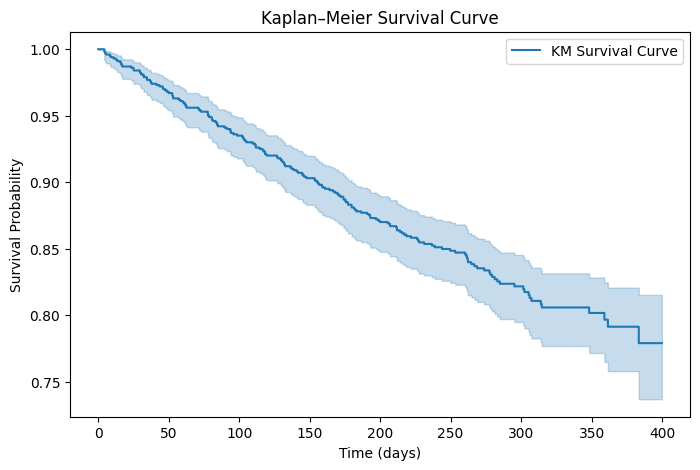

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8, 5))
kmf.fit(df["T"], event_observed=df["E"], label="KM Survival Curve")
kmf.plot()
plt.title("Kaplan–Meier Survival Curve")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()


# Cox Proportional Hazards Model (lifelines)

In [ ]:
from lifelines import CoxPHFitter

features = ["tenure", "num_txn", "avg_amount"]

cph = CoxPHFitter()
cph.fit(
    df[features + ["T", "E"]],
    duration_col="T",
    event_col="E"
)

cph.print_summary()

# Coefficients :
# - coef < 0 → feature giúp giảm hazard (giữ user lâu hơn)
# - exp(coef) = hazard ratio


<lifelines.CoxPHFitter: fitted with 1000 total observations, 823 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 177
   partial log-likelihood = -1106.53
         time fit was run = 2025-12-23 12:03:13 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
tenure     -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
num_txn    -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
avg_amount -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00

            cmp to     z      p  -log2(p)
covariate                                
tenure        0.00 -8.73 <0.005     58.44
num_txn       0.00 -0.68   0.50      1.01
avg_amount    0.00 -2.80   0.01      7.59
---
Concordance = 0.76
Partial AIC = 2219.07
log-likelihood ratio test = 152.33 on 3 df
-log2(p) of ll-ratio test = 106.57

## Plot survival curve for each customer

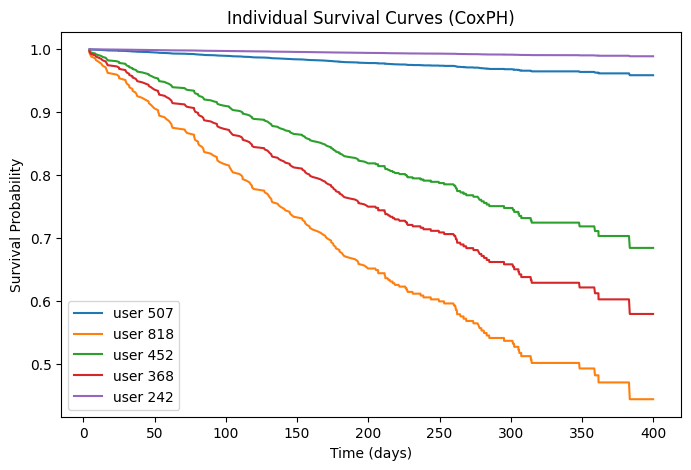

In [ ]:
sample_users = df.sample(5, random_state=1)

plt.figure(figsize=(8, 5))

for _, row in sample_users.iterrows():
    surv_fn = cph.predict_survival_function(row[features].to_frame().T)
    plt.plot(surv_fn.index, surv_fn.values.flatten(), label=f"user {int(row.user_id)}")

plt.title("Individual Survival Curves (CoxPH)")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()


## Evaluate Concordance Index (C-index)

In [ ]:
from lifelines.utils import concordance_index

risk_pred = cph.predict_partial_hazard(df[features])

c_index = concordance_index(
    df["T"],
    -risk_pred,     # negative because higher risk = earlier event
    df["E"]
)

print(f"C-index: {c_index:.4f}")

# Rule of thumb:
# - 0.5 = random
# - 0.6–0.7 = usable
# - 0.7 = strong survival model


C-index: 0.7552


## Integrated Brier Score (IBS)

In [ ]:
from sksurv.metrics import integrated_brier_score
from sksurv.util import Surv

# =========================
# Survival predictions
# =========================
surv_funcs = cph.predict_survival_function(df[features])
# surv_funcs shape: (n_times, n_samples)

# =========================
# VALID time grid (CRITICAL FIX)
# =========================
t_min = df.loc[df["E"] == 1, "T"].min()
t_max = df["T"].max()

times = np.linspace(t_min, t_max * 0.999, 100)

# =========================
# Convert survival funcs
# =========================
surv_preds = np.asarray([
    np.interp(times, surv_funcs.index.values, surv_funcs.iloc[:, i].values)
    for i in range(surv_funcs.shape[1])
])
# shape: (n_samples, n_times)

# =========================
# IBS computation
# =========================
y = Surv.from_arrays(
    event=df["E"].astype(bool),
    time=df["T"]
)

ibs = integrated_brier_score(
    y,      # train
    y,      # test
    surv_preds,
    times
)

print(f"Integrated Brier Score: {ibs:.4f}")

# Interpretation:
# - IBS ↓ tốt hơn
# - 0 = perfect
# - ~0.1–0.2 = khá ổn cho churn survival


Integrated Brier Score: 0.0905
